In [ ]:
import math

import matplotlib.pyplot as plt
import pandas as pd
from imblearn.over_sampling import ADASYN, SMOTE
from imblearn.under_sampling import RepeatedEditedNearestNeighbours
from sklearn.preprocessing import LabelEncoder

In [ ]:
data = pd.read_csv("..\\data\\titanic\\train.csv").drop(
    columns=["Ticket", "Cabin", "Name"]
)

data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [14]:
encoder = LabelEncoder()

In [15]:
data["Sex"] = data["Sex"].apply(lambda x: 1 if x == "male" else 0)
data["Embarked"] = encoder.fit_transform(data["Embarked"])

In [16]:
data["Embarked"].value_counts()

Embarked
2    644
0    168
1     77
3      2
Name: count, dtype: int64

In [17]:
def plot_histograms_grid(
    df: pd.DataFrame, columns: list = None, figsize=(12, 8), bins=30
):
    """
    Строит гистограммы для указанных колонок DataFrame в виде сетки.

    Параметры:
    ----------
    df : pd.DataFrame
        Исходный DataFrame.
    columns : list, optional
        Список названий колонок, для которых нужно построить гистограммы.
        Если None — используются все числовые колонки.
    figsize : tuple, optional
        Размер фигуры (ширина, высота).
    bins : int, optional
        Количество бинов в гистограмме.
    """
    if columns is None:
        # Берём только числовые колонки, если не указано иное
        columns = df.select_dtypes(include="number").columns.tolist()
    else:
        # Проверяем, что указанные колонки существуют в DataFrame
        missing = set(columns) - set(df.columns)
        if missing:
            raise ValueError(f"Следующие колонки отсутствуют в DataFrame: {missing}")

    n = len(columns)
    if n == 0:
        print("Нет колонок для построения гистограмм.")
        return

    # Определяем размер сетки
    cols = min(3, n)  # максимум 3 графика в строке
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(columns):
        df[col].hist(ax=axes[i], bins=bins, edgecolor="black")
        axes[i].set_title(f"Гистограмма: {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Частота")

    # Скрываем лишние оси, если колонок меньше, чем ячеек сетки
    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

## Распределения изначальной выборки

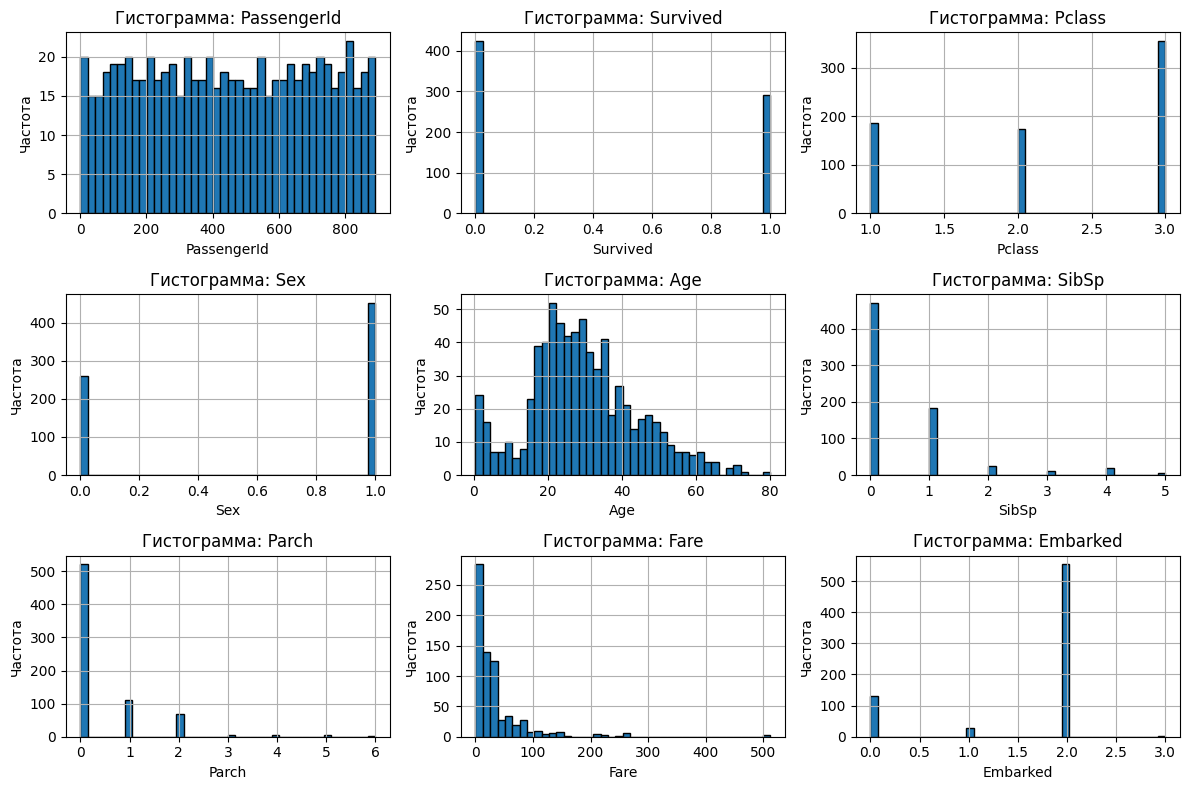

In [ ]:
fig = plot_histograms_grid(df=data, columns=data.columns, bins=40)

### Для класса `1`

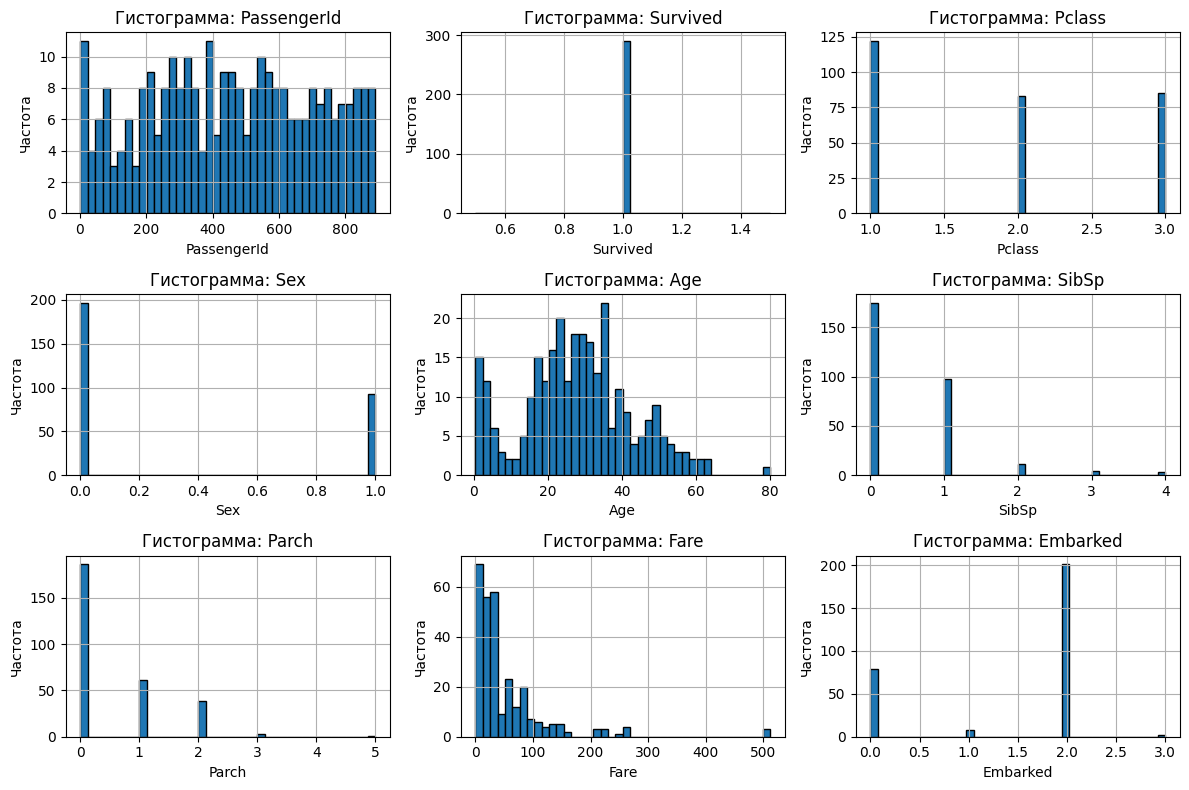

In [ ]:
fig = plot_histograms_grid(
    df=data[data["Survived"] == 1], columns=data.columns, bins=40
)

### Для класса `0`

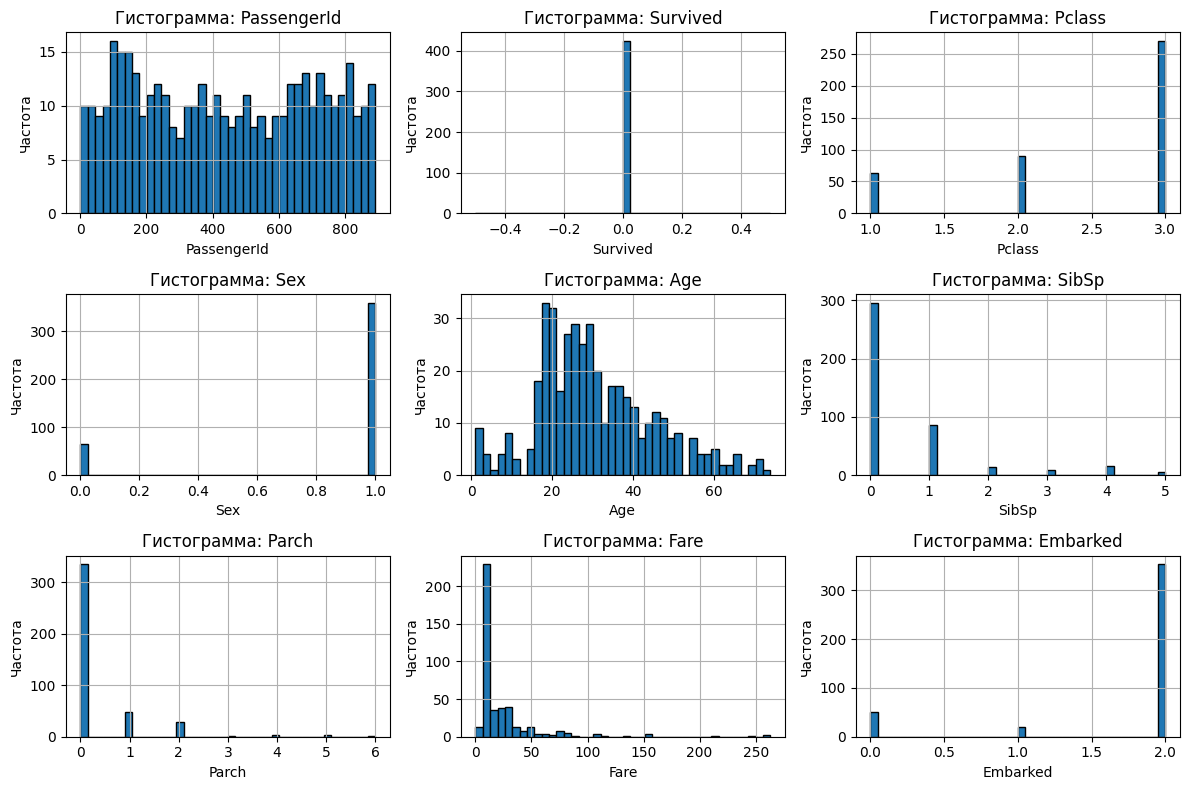

In [ ]:
fig = plot_histograms_grid(
    df=data[data["Survived"] == 0], columns=data.columns, bins=40
)

| Общее распределение | Для класса `1` | Для класса `0`|
|:-:|:-:|:-:|
| 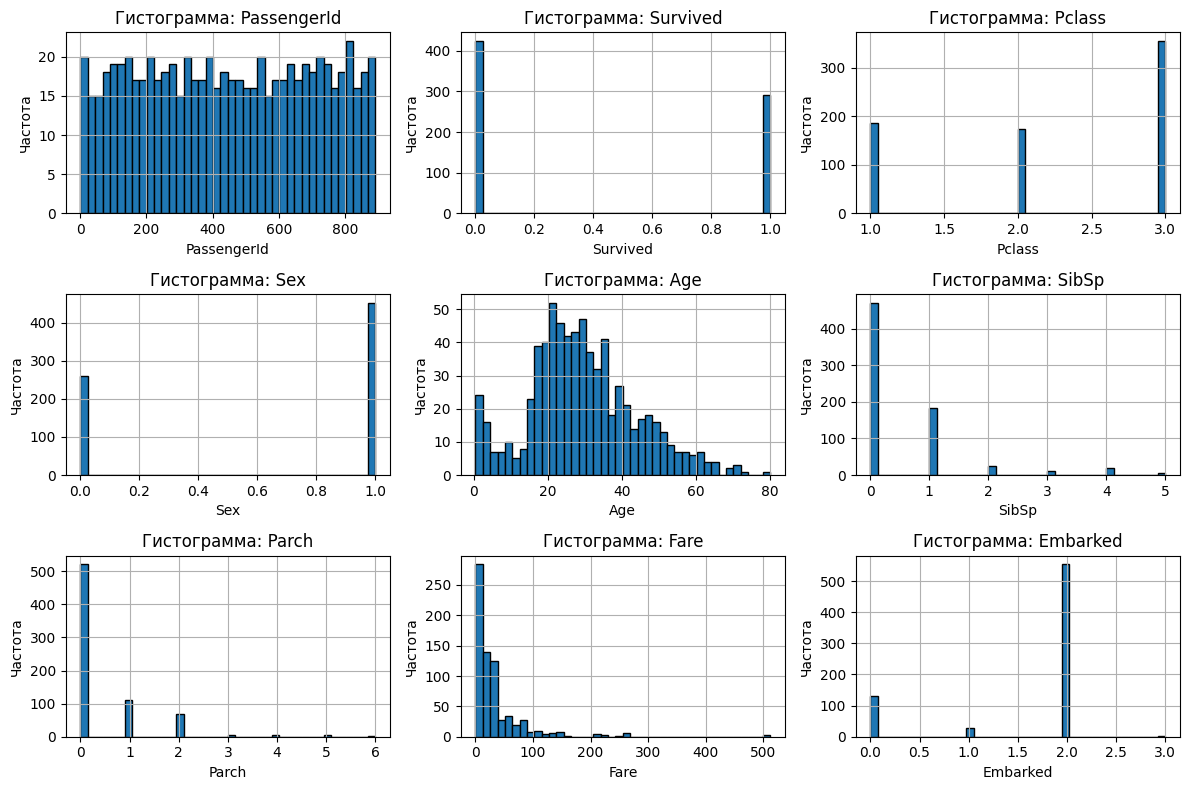 | 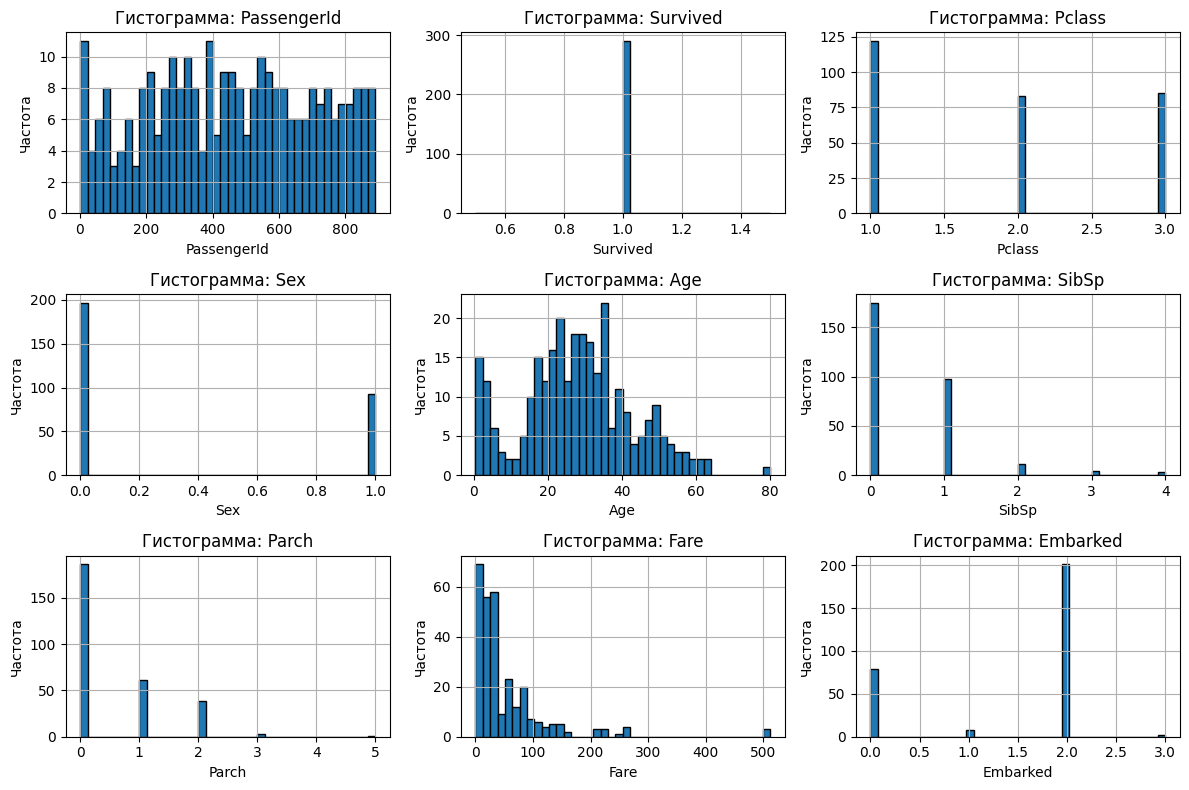|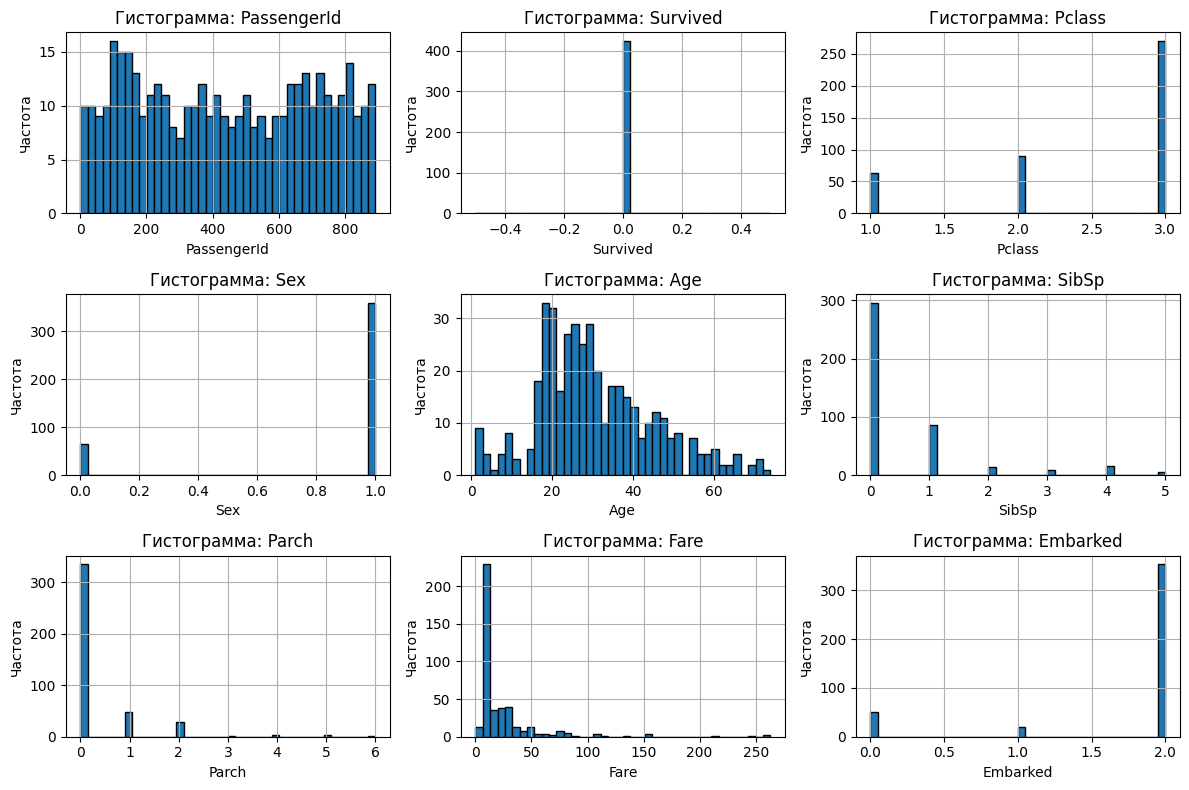 |

## Over-sampling

### Алгоритм `SMOTE`

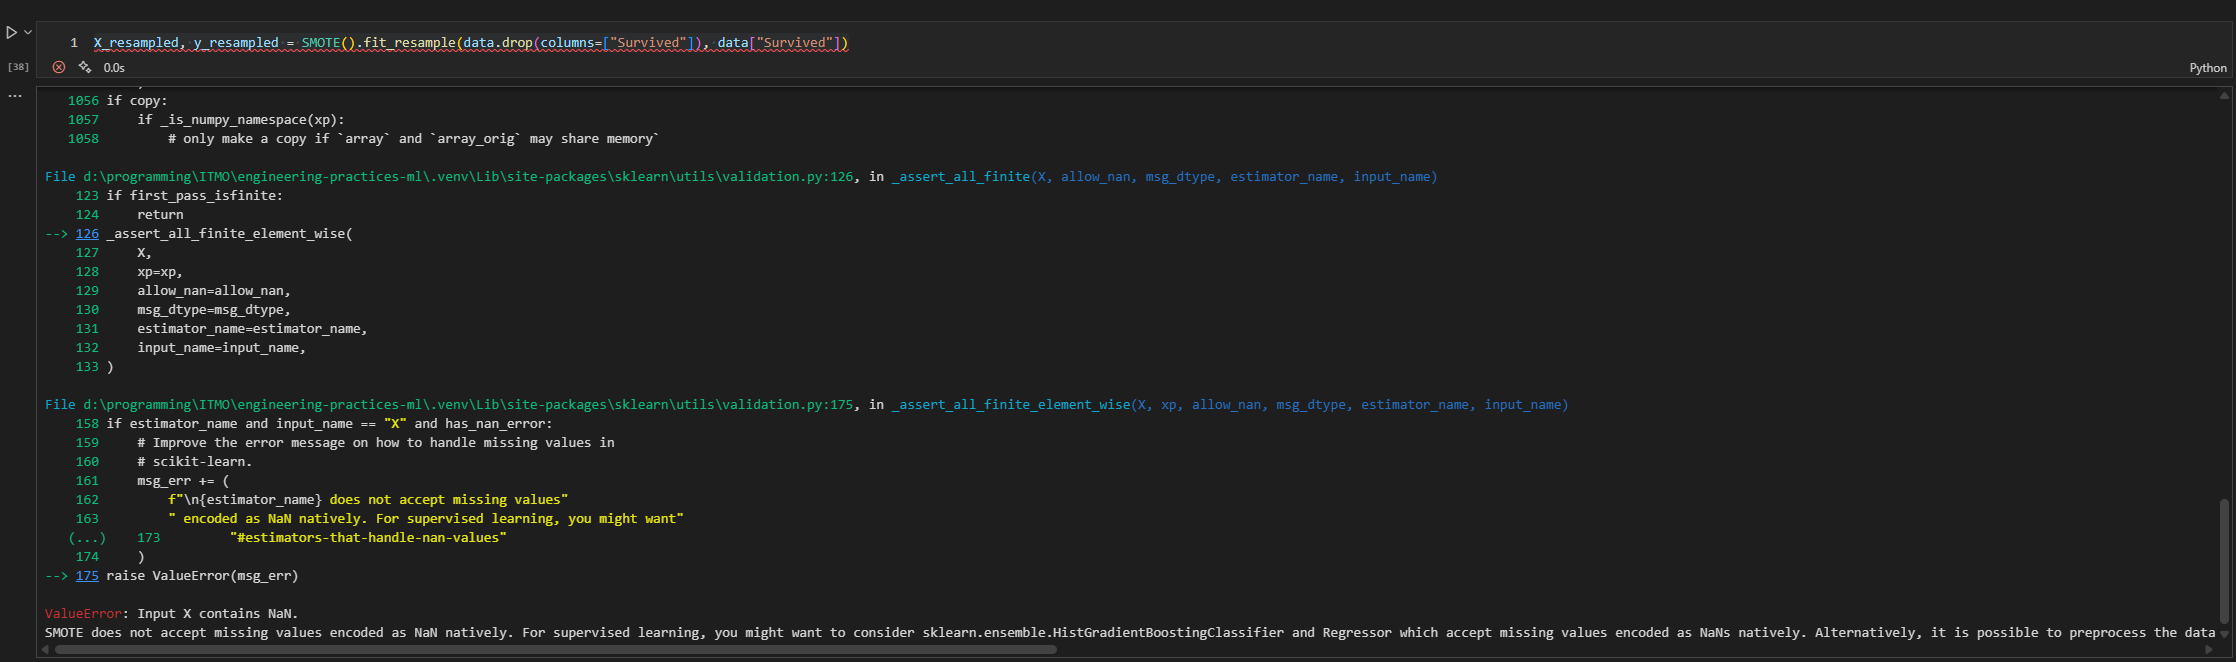

### Алгоритмы не работают с `None`

In [53]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Sex          714 non-null    int64  
 4   Age          714 non-null    float64
 5   SibSp        714 non-null    int64  
 6   Parch        714 non-null    int64  
 7   Fare         714 non-null    float64
 8   Embarked     714 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 55.8 KB


In [ ]:
synthetic_data_x, synthetic_data_y = SMOTE().fit_resample(
    data.drop(columns=["Survived"]), data["Survived"]
)

synthetic_data_x["Survived"] = synthetic_data_y

### Для класса `1`

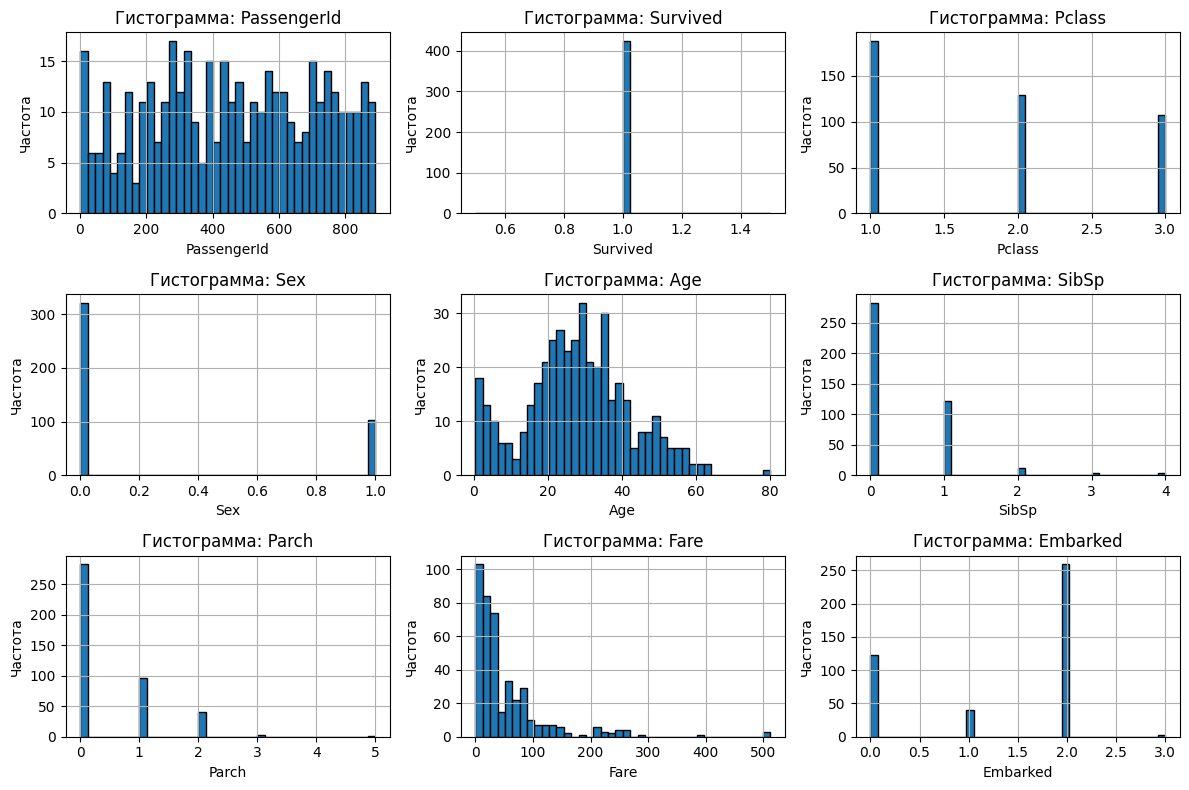

In [ ]:
fig = plot_histograms_grid(
    df=synthetic_data_x[synthetic_data_x["Survived"] == 1],
    columns=data.columns,
    bins=40,
)

### Для класса `0`

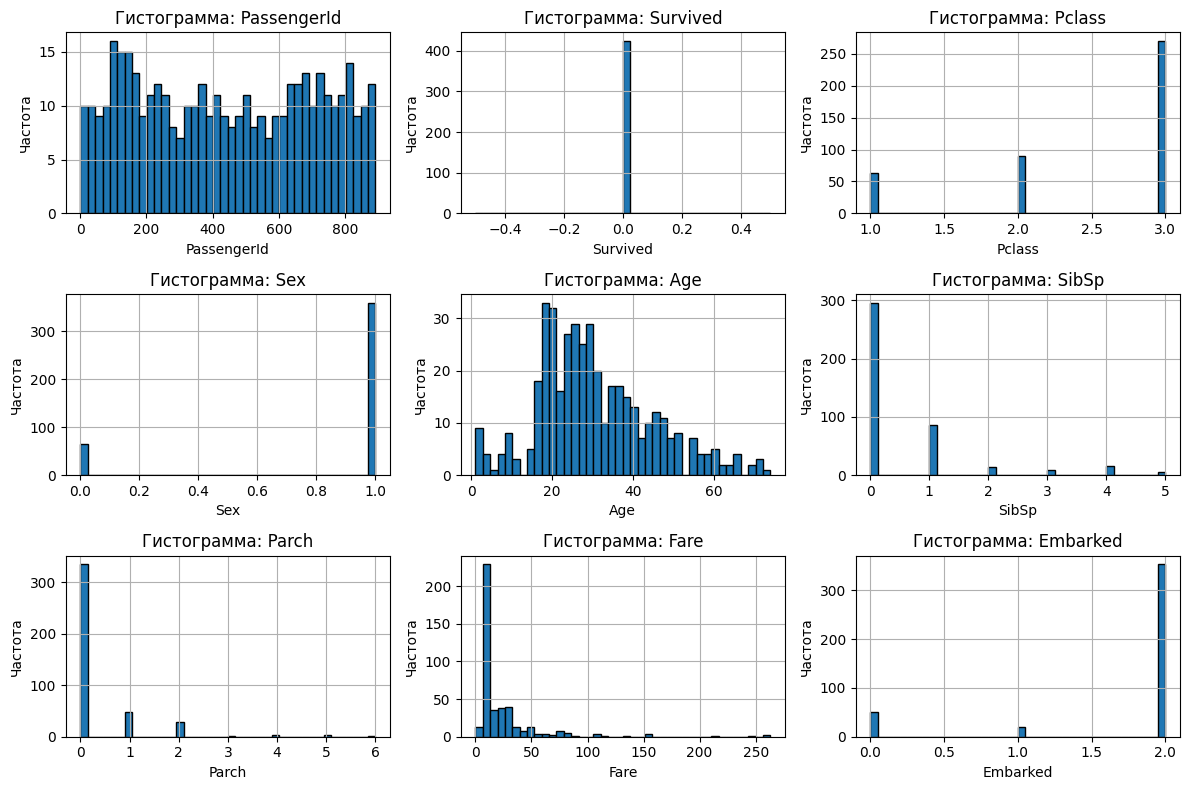

In [ ]:
fig = plot_histograms_grid(
    df=synthetic_data_x[synthetic_data_x["Survived"] == 0],
    columns=data.columns,
    bins=40,
)

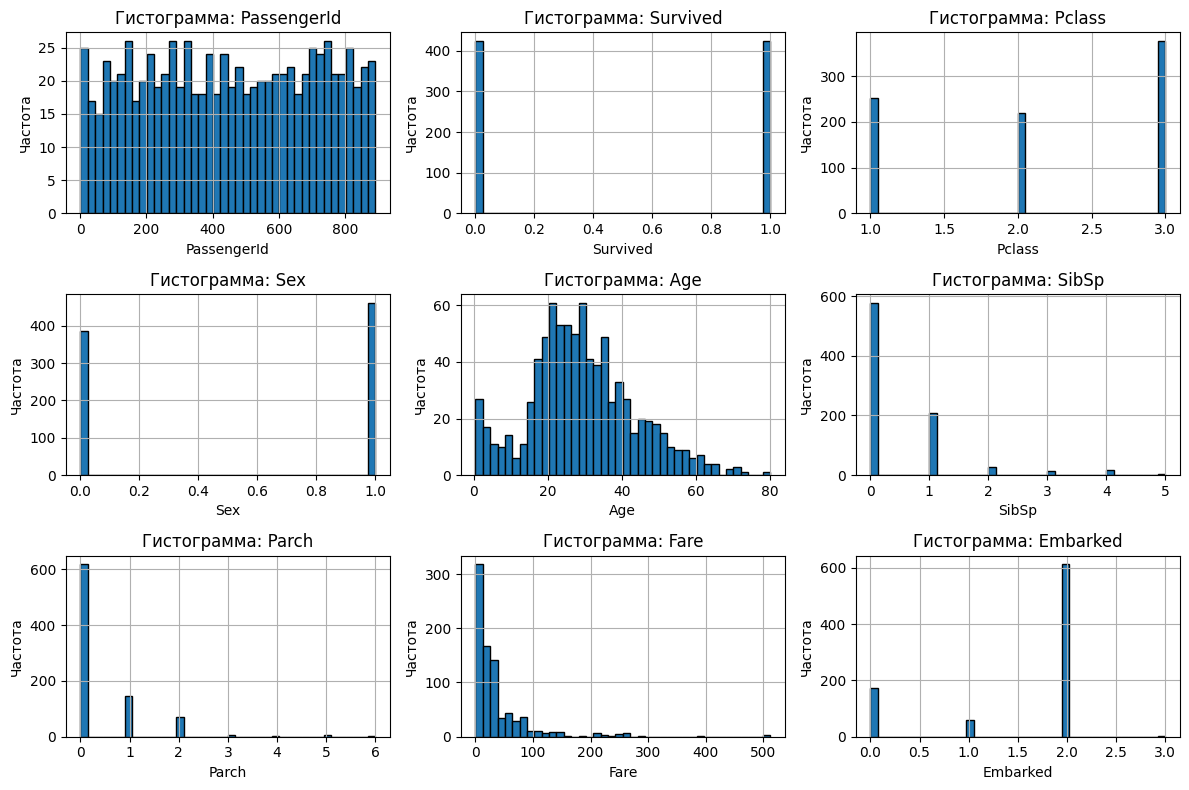

In [ ]:
fig = plot_histograms_grid(df=synthetic_data_x, columns=data.columns, bins=40)

| Общее распределение | Для класса `1` | Для класса `0`|
|:-:|:-:|:-:|
| 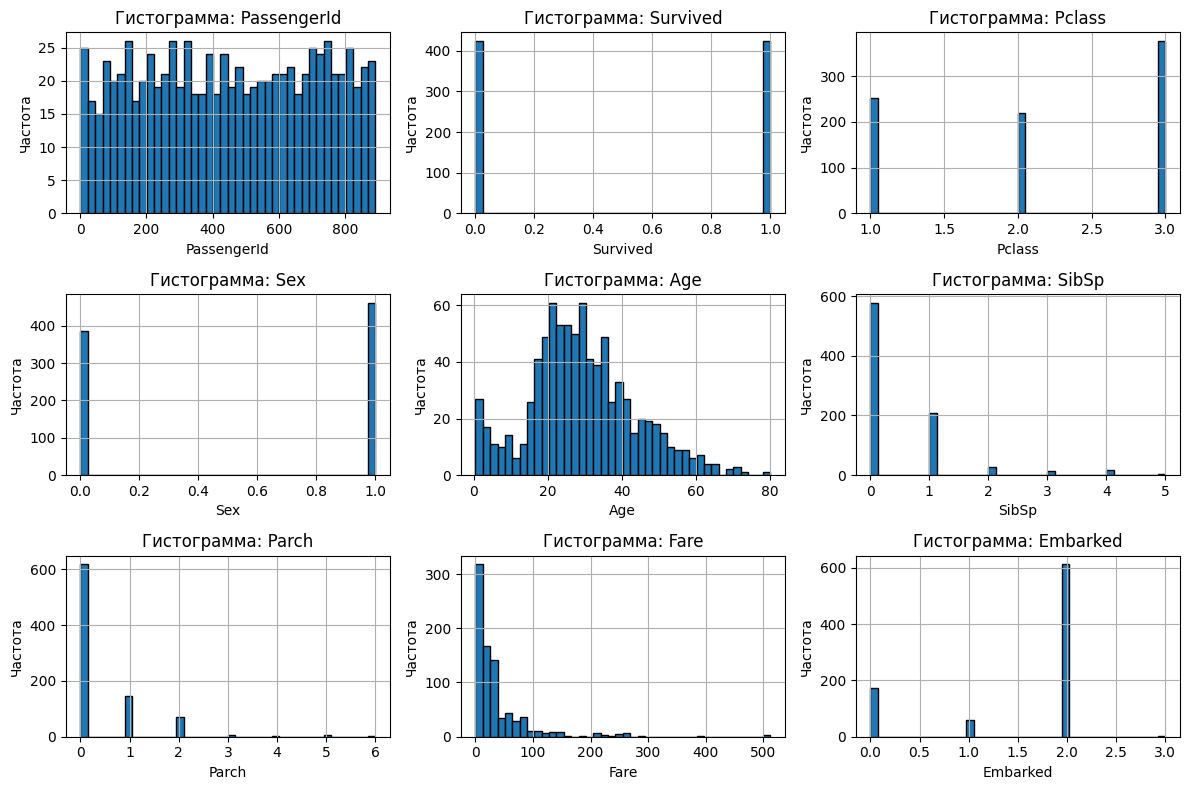 | 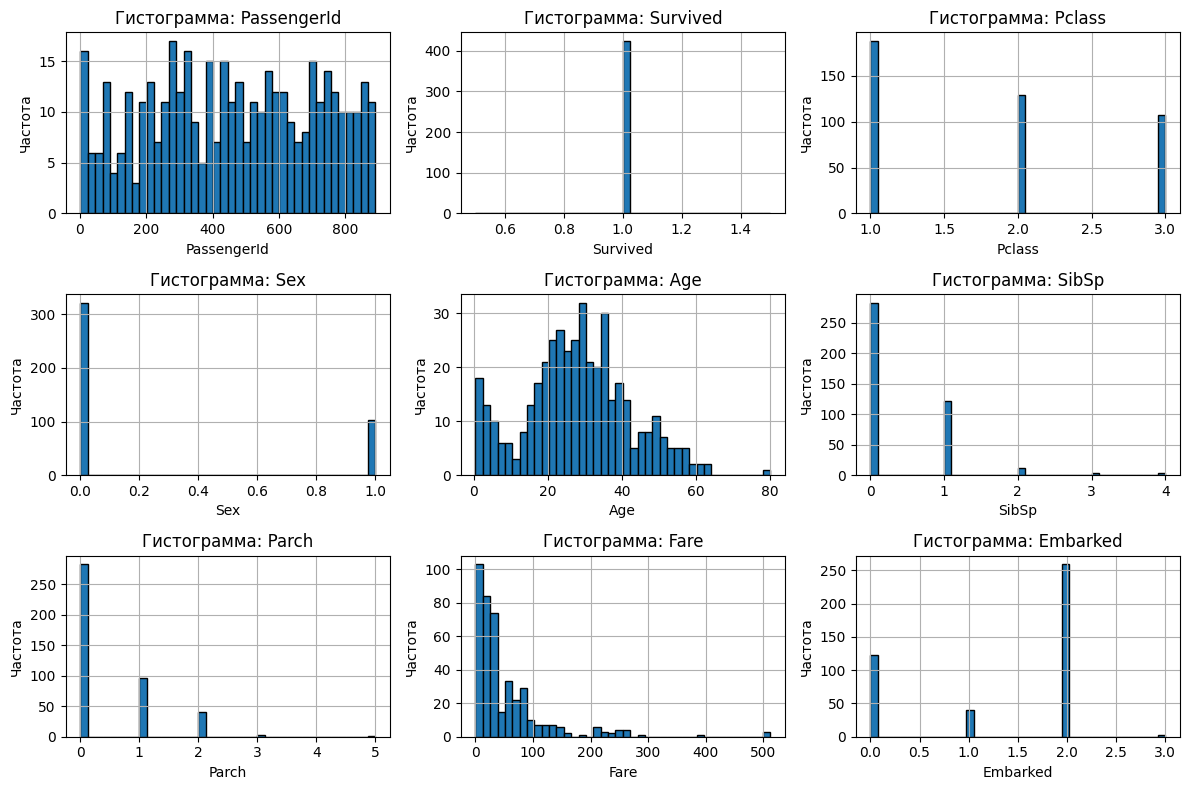 | 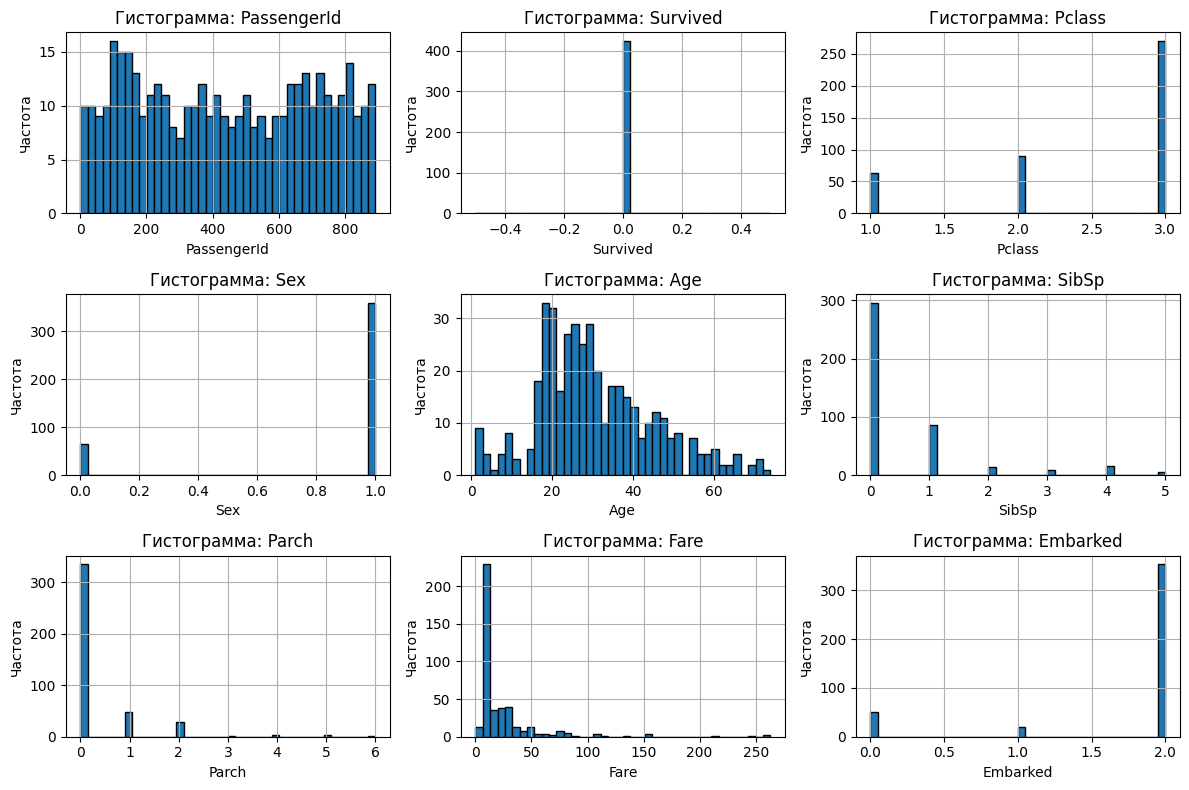 |

## Сравним с изначальным

| Данные | Общее распределение | Для класса `1` | Для класса `0`|
|:-:|:-:|:-:|:-:|
| **Исходные** | 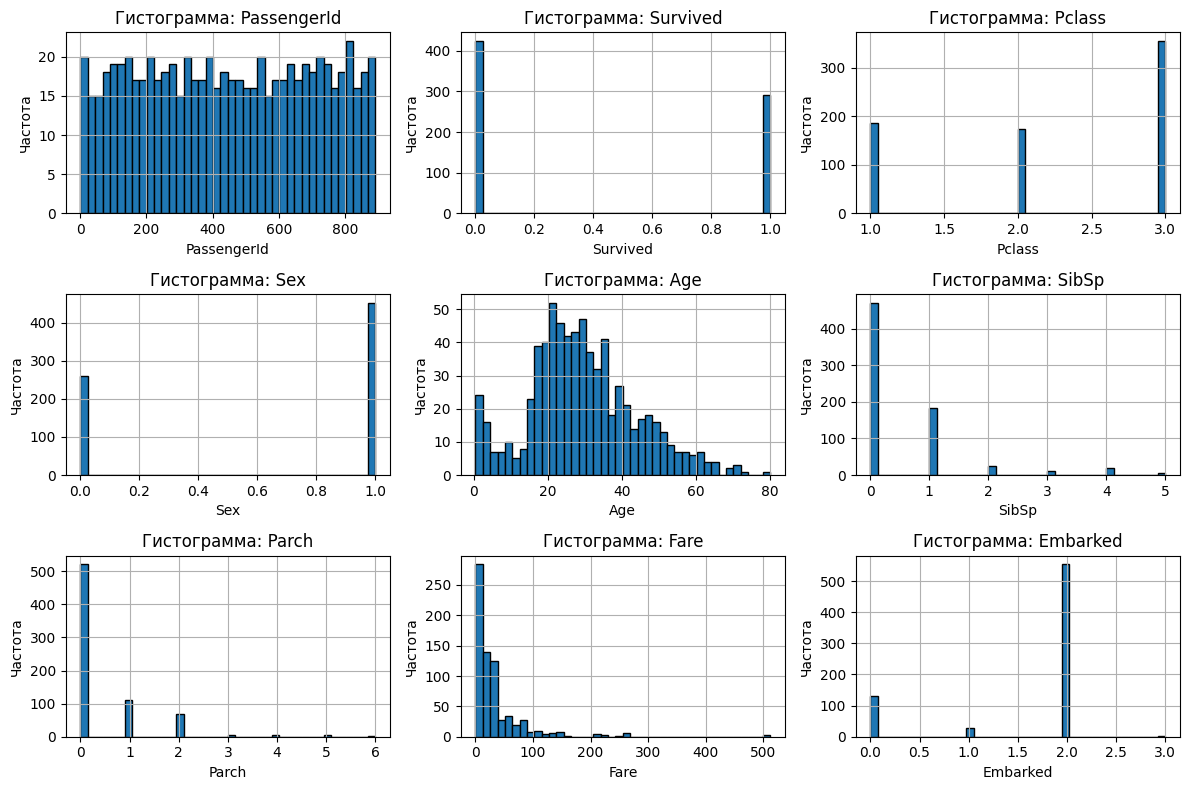 | 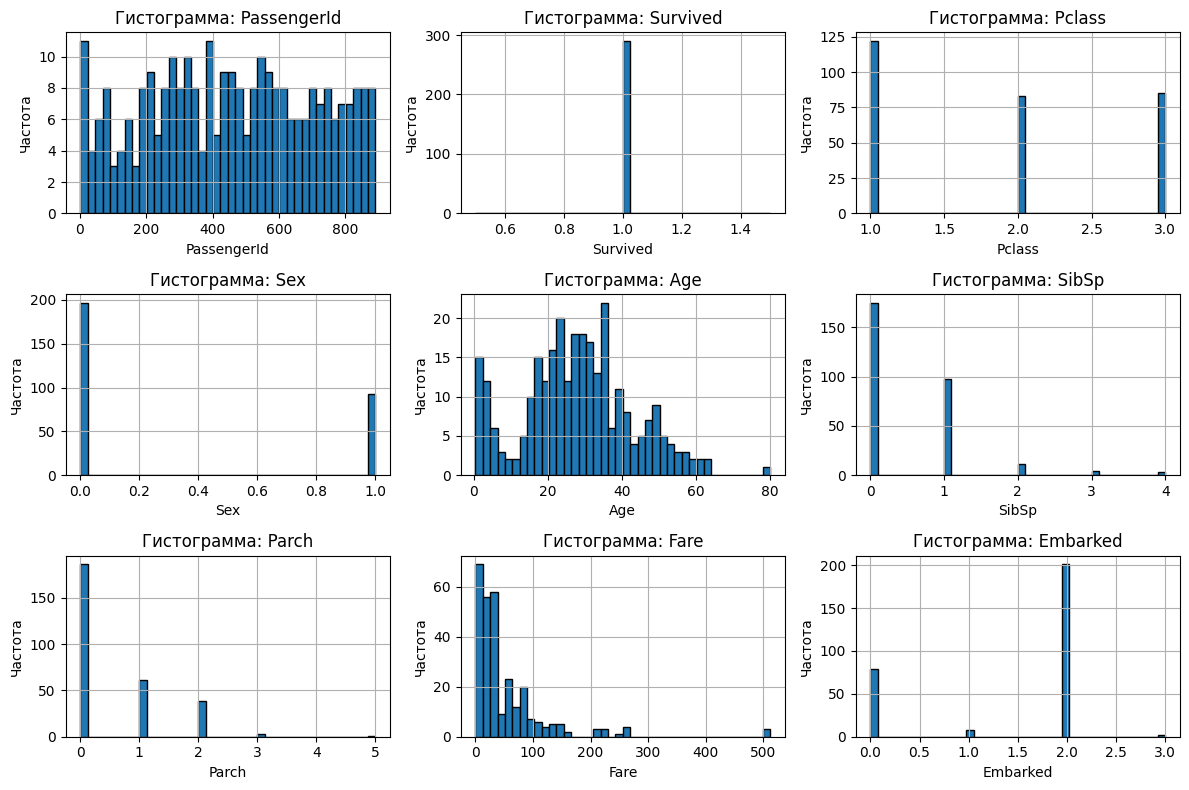 | 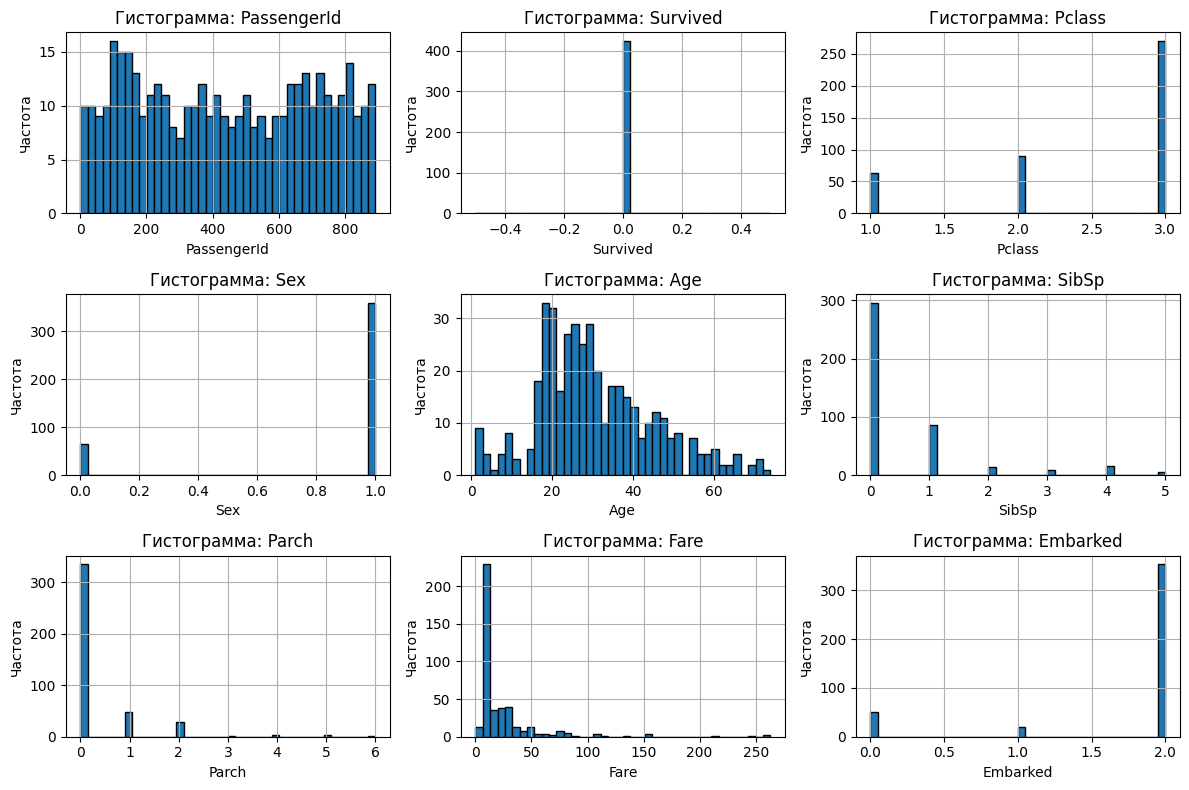 |
| **SMOTE** | 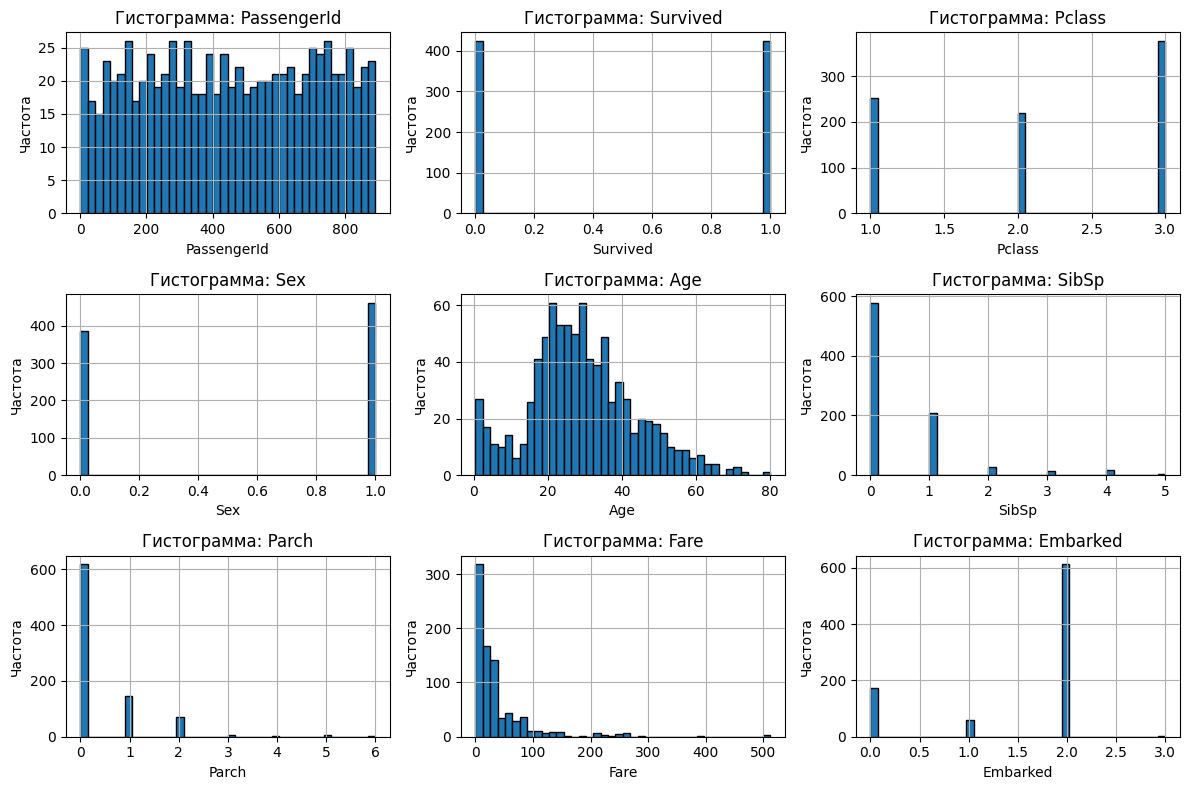 | 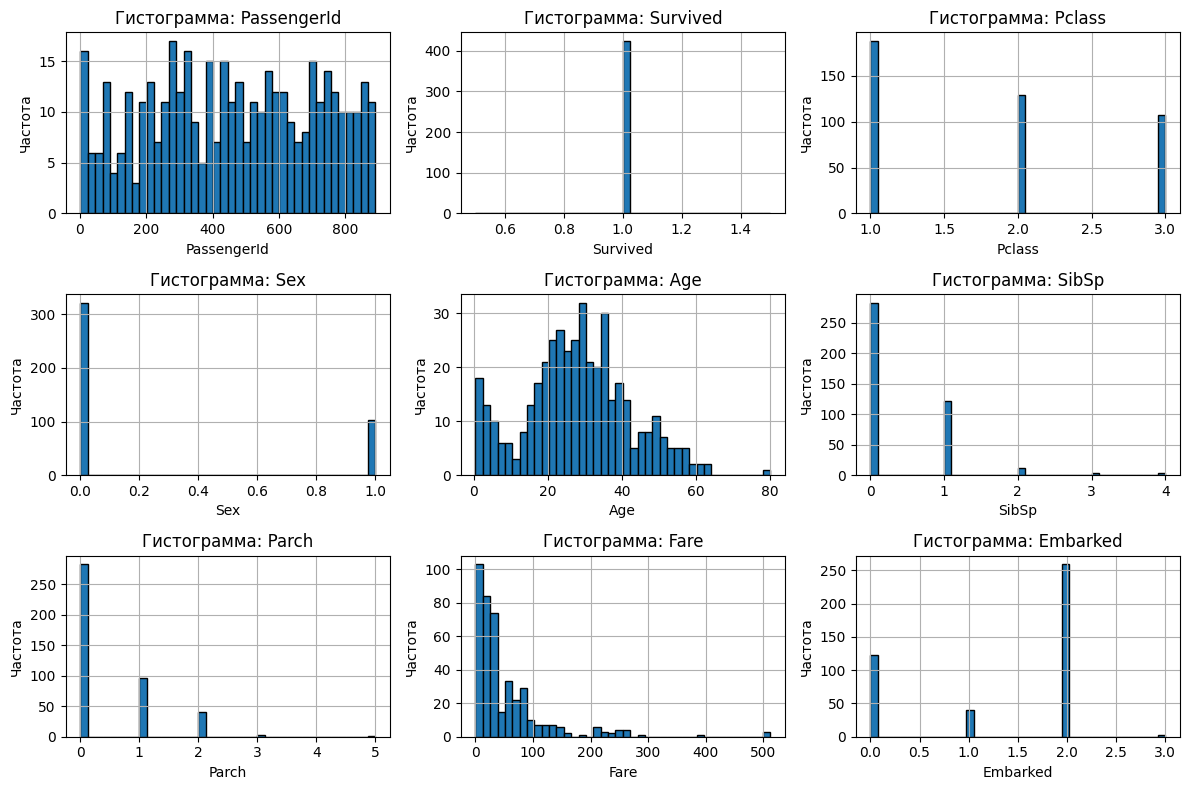 | 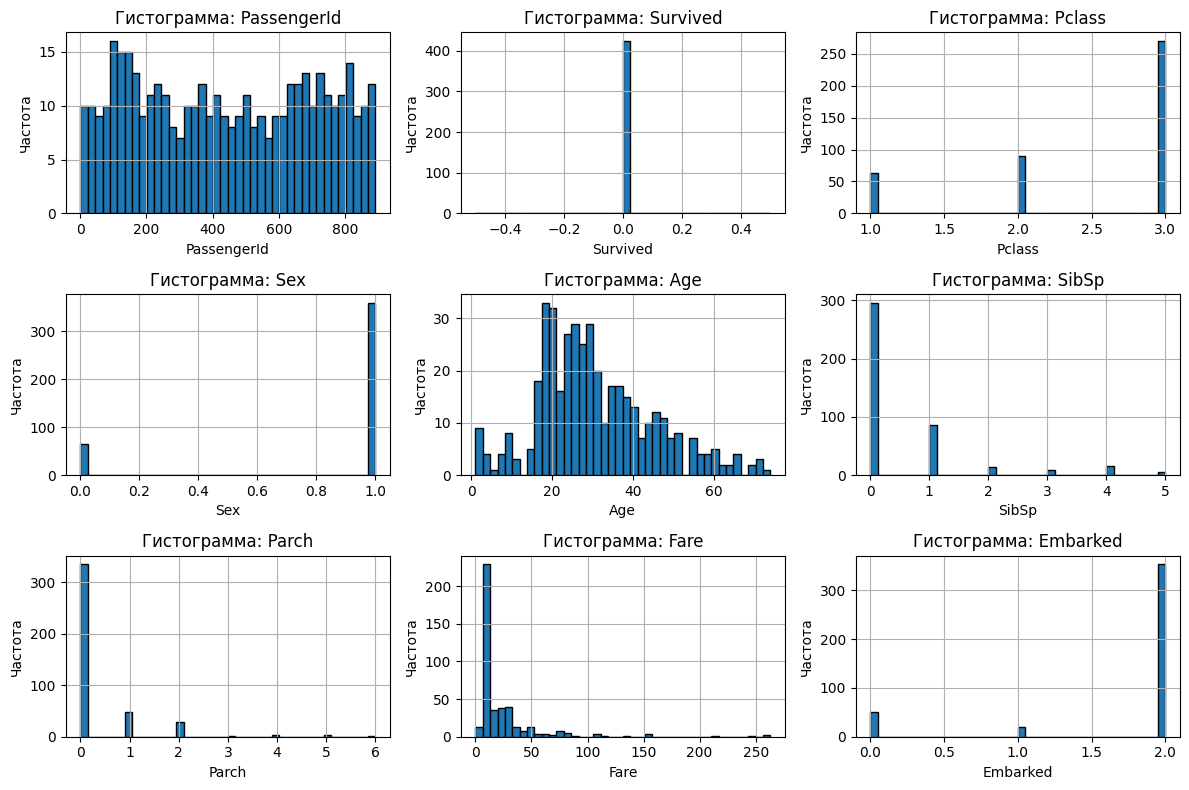 |

### Алгоритм `ADASYN`

In [ ]:
synthetic_data_x, synthetic_data_y = ADASYN().fit_resample(
    data.drop(columns=["Survived"]), data["Survived"]
)

synthetic_data_x["Survived"] = synthetic_data_y

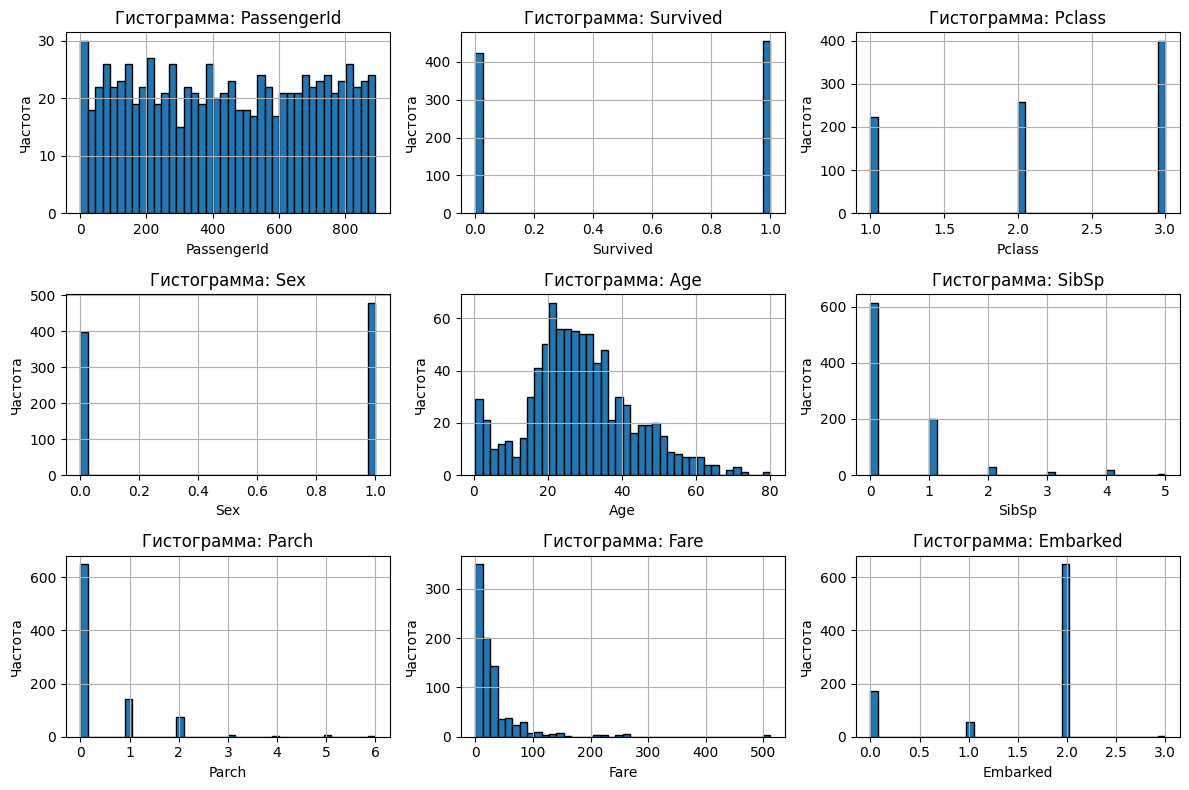

In [ ]:
fig = plot_histograms_grid(df=synthetic_data_x, columns=data.columns, bins=40)

### Для класса `1`

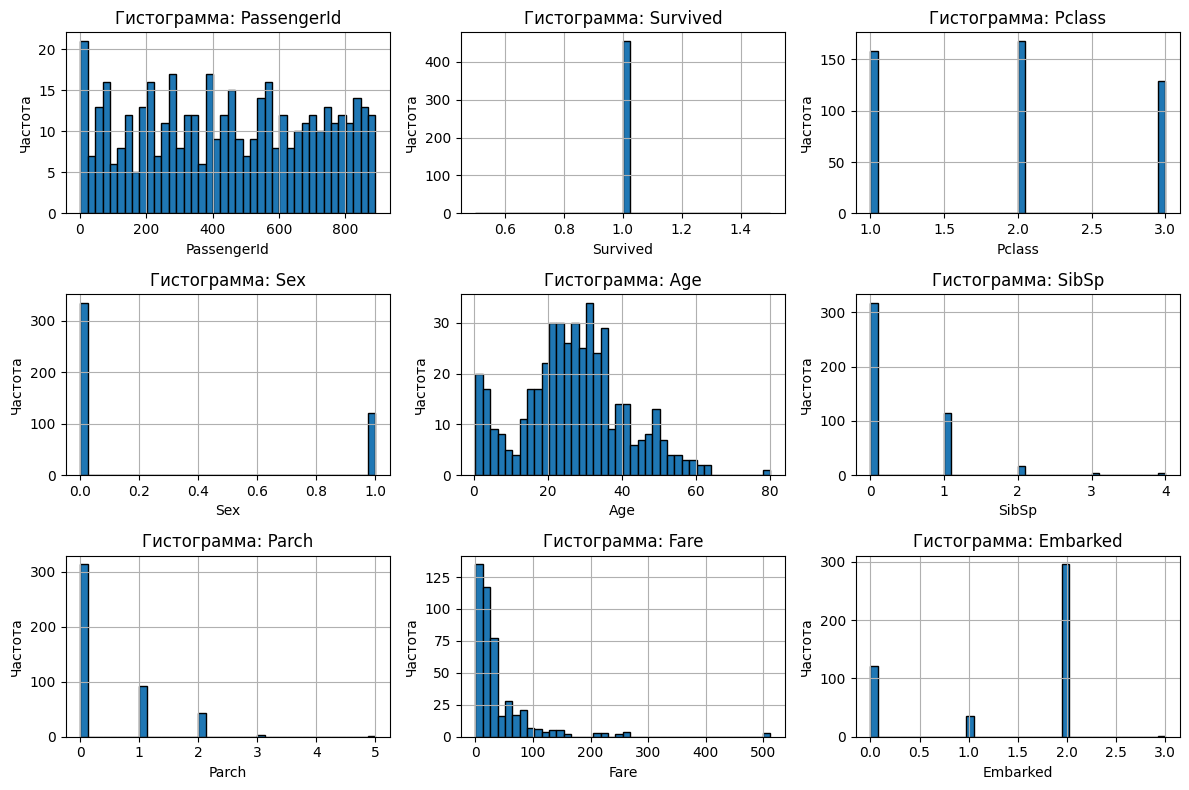

In [ ]:
fig = plot_histograms_grid(
    df=synthetic_data_x[synthetic_data_x["Survived"] == 1],
    columns=data.columns,
    bins=40,
)

### Для класса `0`

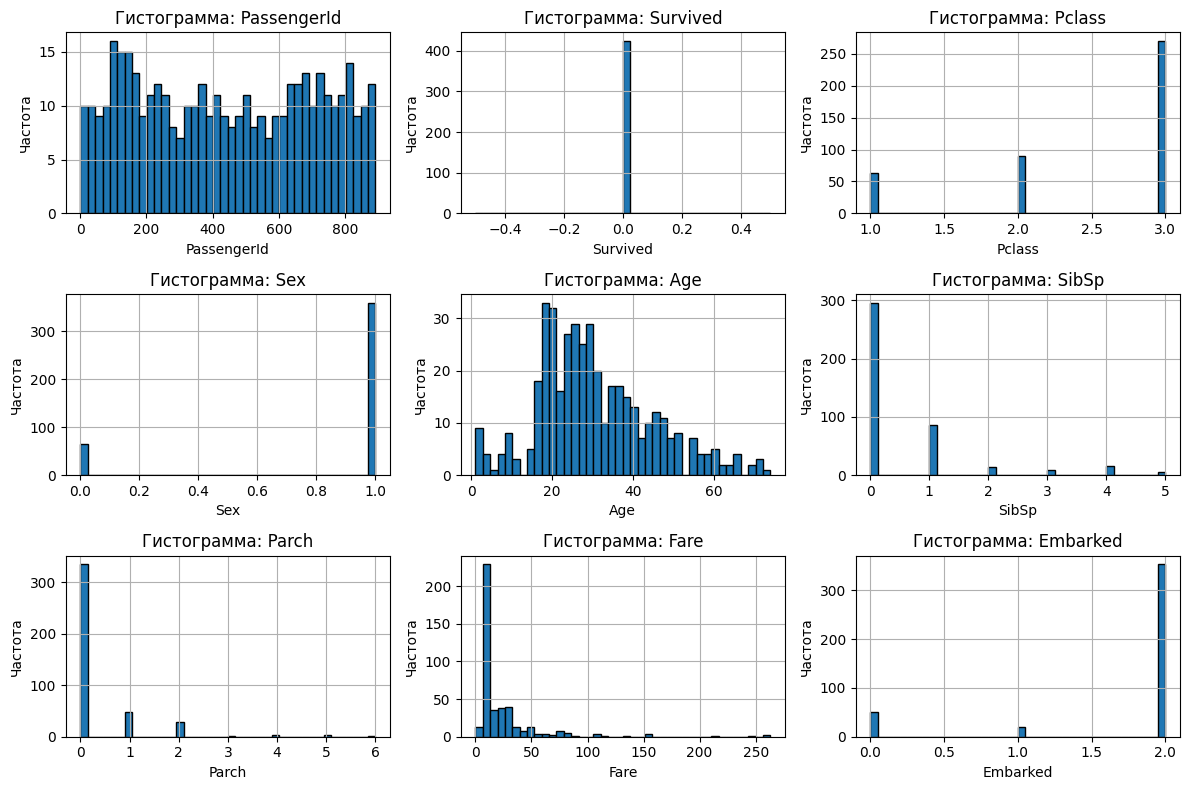

In [ ]:
fig = plot_histograms_grid(
    df=synthetic_data_x[synthetic_data_x["Survived"] == 0],
    columns=data.columns,
    bins=40,
)

### Какие ещё есть алгоритмы

### Обычный SMOTE
Алгоритм SMOTE не накладывает дополнительных ограничений и случайным образом выбирает все доступные ближайшие соседи из миноритарного класса для генерации новых синтетических примеров.

### Borderline-SMOTE
Алгоритм `BorderlineSMOTE` классифицирует каждый пример из миноритарного класса на три категории с использованием параметра `m_neighbors`:

- **Шум** — все ближайшие соседи принадлежат другому классу;
- **В опасности** — как минимум половина ближайших соседей принадлежит тому же классу;
- **Безопасный** — все ближайшие соседи принадлежат тому же классу.

Генерация новых примеров происходит **только на основе «опасных»** точек.

- **Borderline-1**: при создании синтетического примера учитываются **только соседи из того же класса**, что и исходная точка.
- **Borderline-2**: при создании синтетического примера допускается использование **соседей из любого класса**.

### SVM-SMOTE (`SVMSMOTE`)
Использует **опорные векторы**, найденные с помощью SVM-классификатора, в качестве основы для генерации новых примеров.  
Параметр `C` SVM влияет на количество опорных векторов: при меньшем `C` допускается больше опорных векторов, что может привести к более агрессивной генерации.

Как и в `BorderlineSMOTE`, параметр `m_neighbors` определяет окрестность для оценки окружения точек.

### KMeans-SMOTE (`KMeansSMOTE`)
Сначала применяет **кластеризацию KMeans** к данным. Затем SMOTE применяется **внутри каждого кластера**, причём объём генерации зависит от плотности кластера: в более разреженных кластерах создаётся больше синтетических примеров.

### ADASYN (Adaptive Synthetic Sampling)
Работает аналогично обычному SMOTE, но **адаптирует количество синтетических примеров** для каждой исходной точки.  
Чем больше соседей из других классов в окрестности точки (то есть чем сложнее классифицировать её правильно), тем **больше синтетических примеров** создаётся в этой области.  
Параметр `m_neighbors` в ADASYN эквивалентен `k_neighbors` в SMOTE и задаёт размер окрестности.

## Under-sampling

In [19]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Sex          714 non-null    int64  
 4   Age          714 non-null    float64
 5   SibSp        714 non-null    int64  
 6   Parch        714 non-null    int64  
 7   Fare         714 non-null    float64
 8   Embarked     714 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 55.8 KB


In [ ]:
synthetic_data_x, synthetic_data_y = RepeatedEditedNearestNeighbours().fit_resample(
    data.drop(columns=["Survived"]), data["Survived"]
)

synthetic_data_x["Survived"] = synthetic_data_y

### Для класса `1`

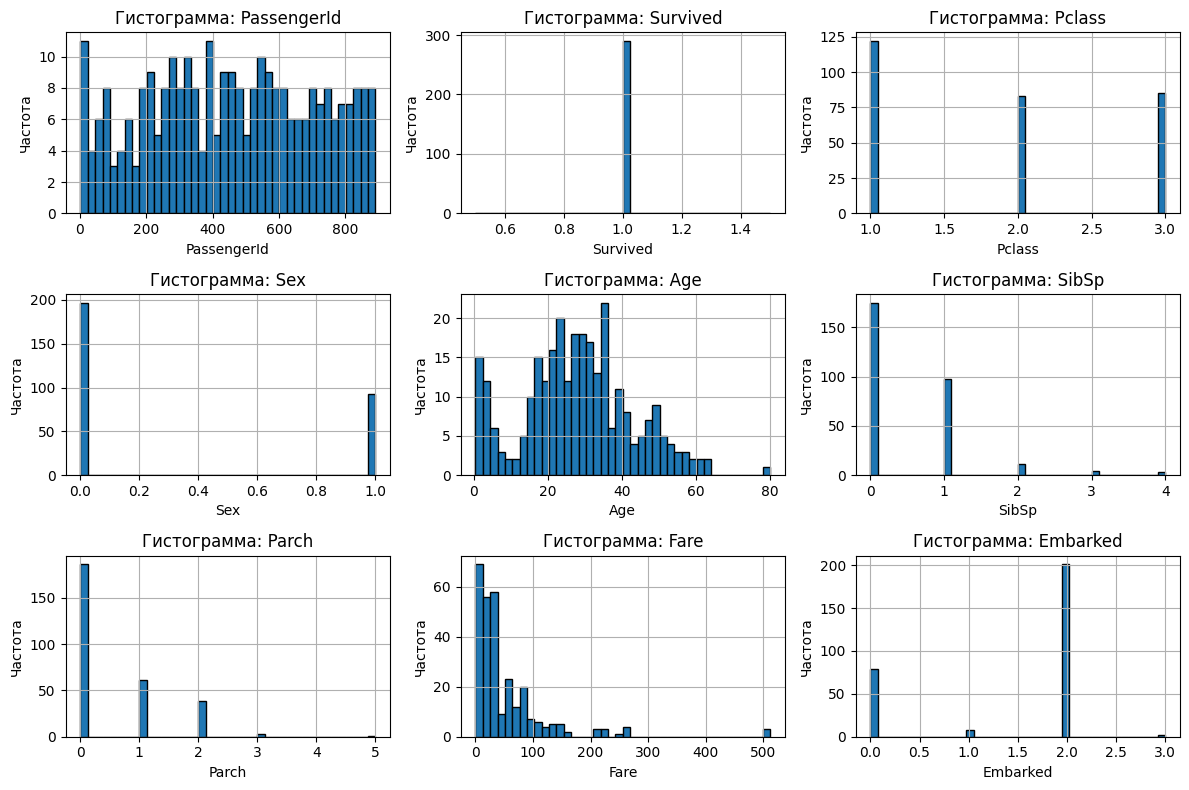

In [ ]:
fig = plot_histograms_grid(
    df=synthetic_data_x[synthetic_data_x["Survived"] == 1],
    columns=data.columns,
    bins=40,
)

### Для класса `0`

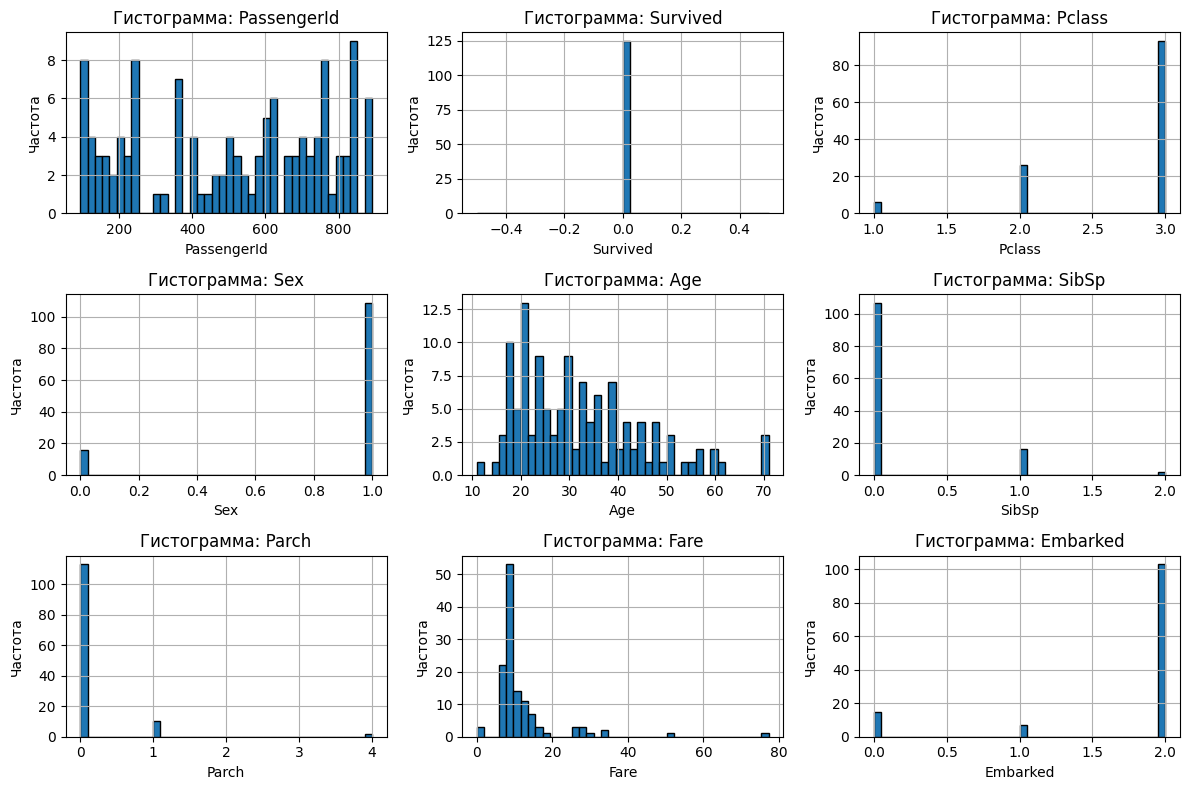

In [ ]:
fig = plot_histograms_grid(
    df=synthetic_data_x[synthetic_data_x["Survived"] == 0],
    columns=data.columns,
    bins=40,
)

| Данные | Для класса `1` | Для класса `0`|
|:-:|:-:|:-:|
| **Изначальные** | 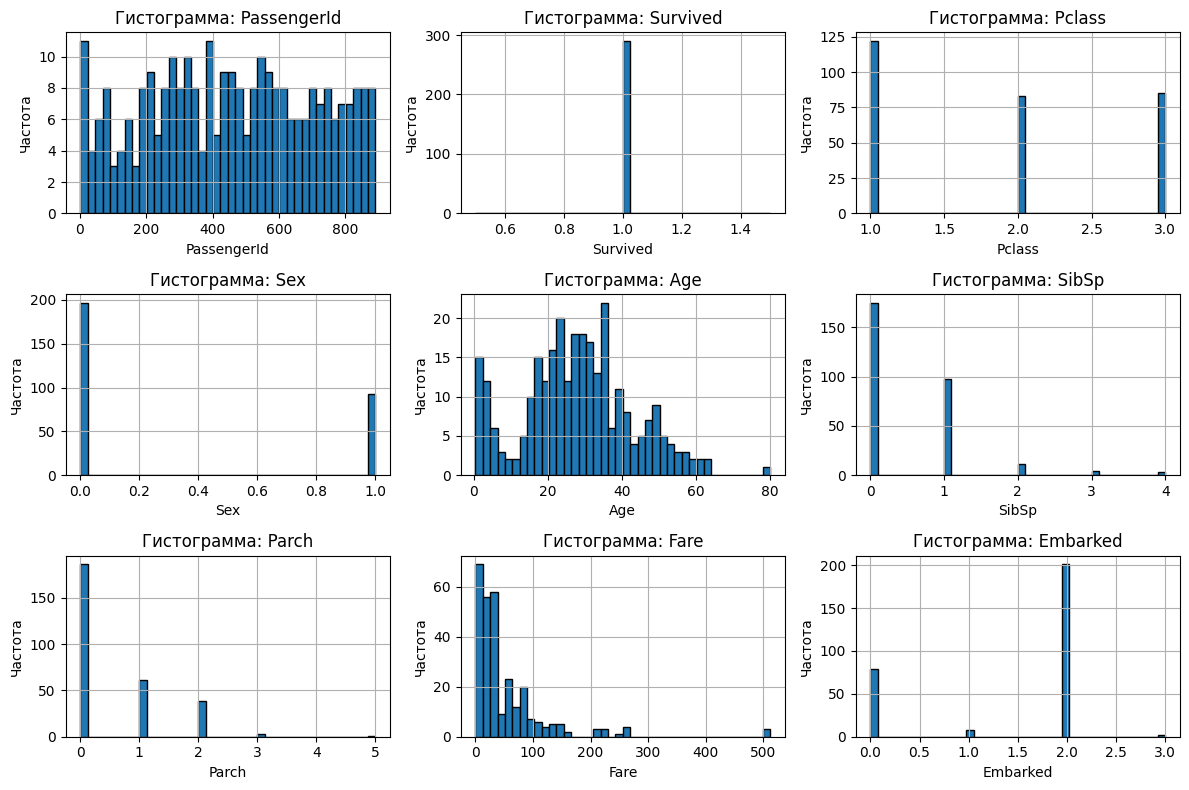 | 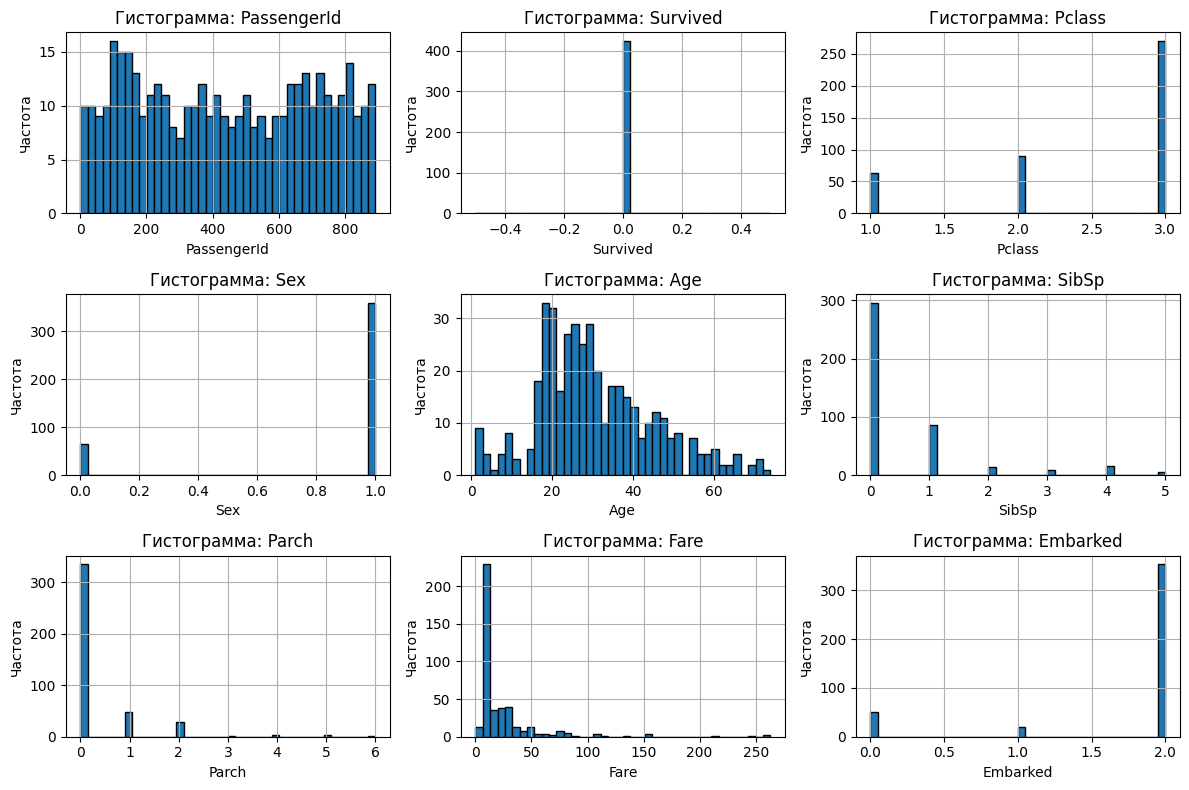 |
| **RepeatedEditedNearestNeighbours** | 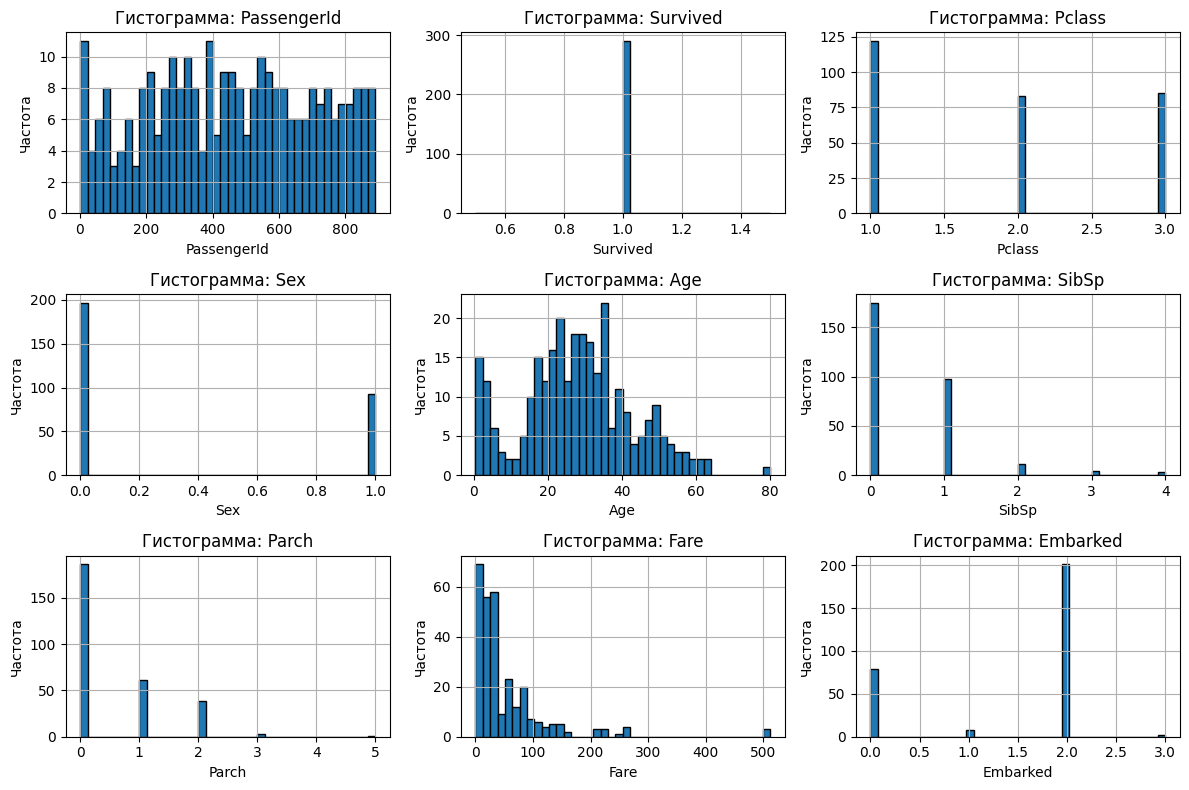 | 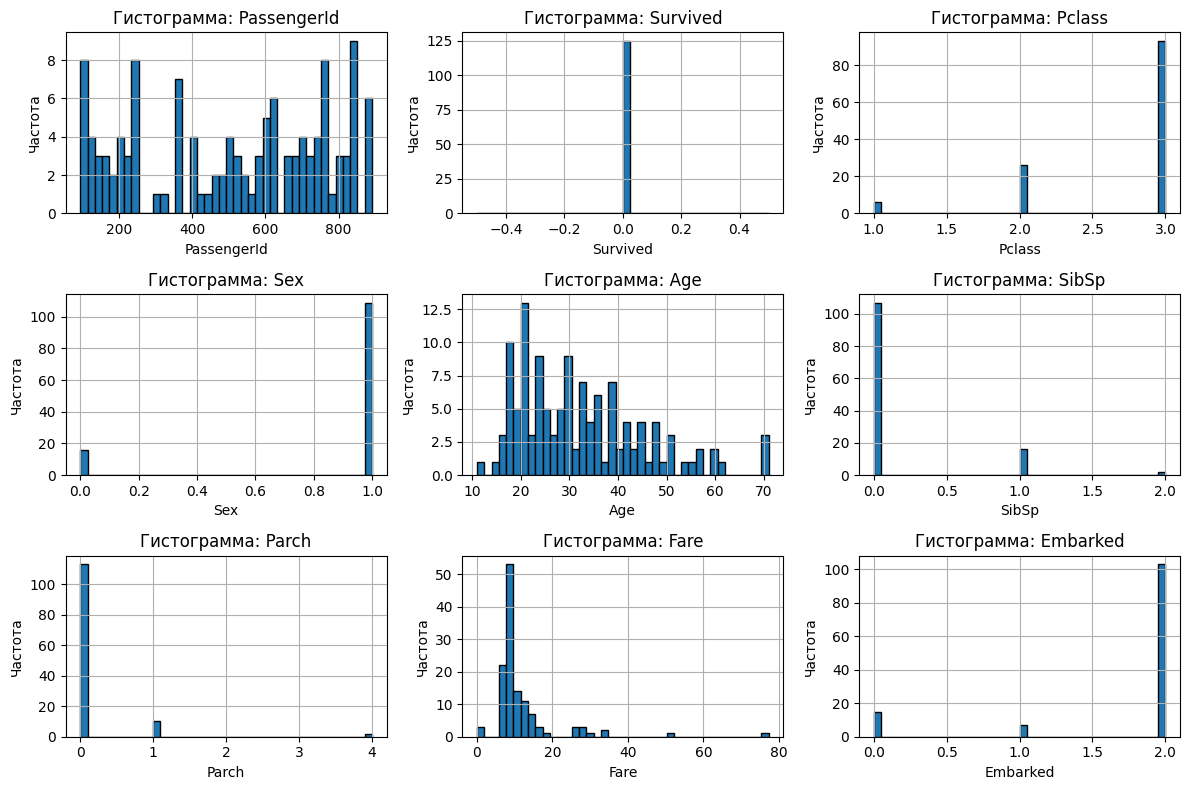 |

### Данный алгоритм работает по следующему принципу

1. Обучите алгоритм K-ближайших соседей на всём наборе данных.
2. Найдите K ближайших соседей для каждого наблюдения (только для целевых классов).
3. Удалите наблюдения, если хотя бы одно или большинство его соседей принадлежат к другому классу.
4. Повторяем шаги 1-3 пока не выполняется одно из условий ниже
   1. Не достигли максимального кол-ва итераций
   2. Класс большинства стал классом меньшинства
   3. Больше не удаляются элементы 

### Алгоритмы Under-sampling

#### 1. **RandomUnderSampler**
Случайным образом удаляет объекты из **мажоритарного класса(ов)** до достижения заданного соотношения классов. Простейший и самый быстрый метод.

#### 2. **TomekLinks**
Удаляет **Tomek links** — пары ближайших соседей из разных классов, где хотя бы один из объектов принадлежит мажоритарному классу. Это помогает "очистить" границу между классами.

#### 3. **EditedNearestNeighbours (ENN)**
Удаляет объекты, класс которых **не совпадает с классом большинства их k ближайших соседей**. Может применяться ко всем классам или только к мажоритарному.

#### 4. **RepeatedEditedNearestNeighbours (RENN)**
Повторно применяет ENN до тех пор, пока не перестанут удаляться объекты или пока не будет достигнуто максимальное число итераций.

#### 5. **AllKNN**
Похож на ENN, но на каждой итерации увеличивает значение **k** (число соседей), начиная с 1 до заданного максимума, и удаляет несогласованные объекты на каждом шаге.

#### 6. **NeighbourhoodCleaningRule (NCR)**
Комбинирует ENN и правило очистки: сначала применяет ENN к мажоритарному классу, затем удаляет мажоритарные объекты, которые являются соседями ошибочно классифицированных миноритарных объектов.

#### 7. **CondensedNearestNeighbour (CNN)**
Создаёт "сжатый" набор данных, сохраняя только те объекты, которые необходимы для корректной классификации с помощью **1NN**. Часто оставляет много мажоритарных объектов и чувствителен к шуму.

#### 8. **OneSidedSelection (OSS)**
Комбинирует **CNN** и **Tomek links**: сначала удаляет Tomek links, затем применяет CNN только к мажоритарному классу.

#### 9. **InstanceHardnessThreshold (IHT)**
Удаляет объекты мажоритарного класса, которые **сложны для классификации** (низкая предсказанная вероятность правильного класса), используя заданную ML-модель (например, логистическую регрессию или дерево решений).

#### 10. **NearMiss**
Существует три версии:
- **NearMiss-1**: выбирает мажоритарные объекты, **ближайшие к ближайшим миноритарным**.
- **NearMiss-2**: выбирает мажоритарные объекты, **ближайшие к самым удалённым миноритарным**.
- **NearMiss-3**: для каждого миноритарного объекта выбирает **k ближайших мажоритарных**, чтобы сохранить локальную информацию.